In [2]:
import pandas as pd 
import torch 
import numpy 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import defaultdict

In [3]:
human_eval = pd.read_csv('logs/outputs/entropy/humanevak.csv')
gradesm = pd.read_csv("logs/outputs/entropy/gsm8k.csv")
sharegpt = pd.read_csv('logs/outputs/entropy/sharegpt.csv')

In [19]:
human_eval.head()

,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,entropy_smoothed_w16,entropy_smoothed_w32,accepted_text
0,0,0,149,3,4,3,"(0, 0, 0)","(0, 0, 0, 1)",1.970996,1.970996,1.970996,1.970996,Here's the
1,0,1,153,3,4,3,"(2, 0, 0)","(2, 0, 0)",1.200216,1.530550,1.573174,1.579489,completed function:\n
2,0,2,157,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.110084,0.916295,1.053686,1.074057,```python\nfrom typing
3,0,3,162,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.000171,0.581255,0.764289,0.792668,import List\n\ndef
4,0,4,167,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.001193,0.391119,0.591363,0.624165,has_close_elements


MACD style features

In [20]:
dataframes = {'human_eval': human_eval,
              'gsm8k': gradesm,
              'sharegpt': sharegpt}

transformed = defaultdict(dict)

for dataset, df in dataframes.items():
    macd_df = df.copy()

    macd_df['macd_4_16']  = macd_df['entropy_smoothed_w4']  - macd_df['entropy_smoothed_w16']
    macd_df['macd_4_32']  = macd_df['entropy_smoothed_w4']  - macd_df['entropy_smoothed_w32']
    macd_df['macd_16_32'] = macd_df['entropy_smoothed_w16'] - macd_df['entropy_smoothed_w32']

    for col in ['macd_4_16', 'macd_4_32', 'macd_16_32']:
        macd_df[f'{col}_signal'] = macd_df.groupby('sample_idx')[col].transform(
            lambda x: x.ewm(span=4, adjust=False).mean()
        )
        macd_df[f'{col}_hist'] = macd_df[col] - macd_df[f'{col}_signal']

    macd_df['entropy_div_w4']  = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w4']
    macd_df['entropy_div_w16'] = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w16']
    macd_df['entropy_div_w32'] = macd_df['block_start_entropy'] - macd_df['entropy_smoothed_w32']

    print(f"dataset type: {dataset}")
    display(macd_df.head(3))

    transformed[dataset]['raw'] = macd_df

dataset type: human_eval


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,macd_16_32,macd_4_16_signal,macd_4_16_hist,macd_4_32_signal,macd_4_32_hist,macd_16_32_signal,macd_16_32_hist,entropy_div_w4,entropy_div_w16,entropy_div_w32
0,0,0,149,3,4,3,"(0, 0, 0)","(0, 0, 0, 1)",1.970996,1.970996,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,1,153,3,4,3,"(2, 0, 0)","(2, 0, 0)",1.200216,1.530550,...,-0.006315,-0.017050,-0.025574,-0.019575,-0.029363,-0.002526,-0.003789,-0.330334,-0.372958,-0.379273
2,0,2,157,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",0.110084,0.916295,...,-0.020371,-0.065186,-0.072205,-0.074850,-0.082912,-0.009664,-0.010707,-0.806211,-0.943602,-0.963973


dataset type: gsm8k


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,macd_16_32,macd_4_16_signal,macd_4_16_hist,macd_4_32_signal,macd_4_32_hist,macd_16_32_signal,macd_16_32_hist,entropy_div_w4,entropy_div_w16,entropy_div_w32
0,0,0,133,4,5,4,"(0, 0, 0, 0)","(0, 0, 0, 0)",1.639900,1.639900,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,1,138,4,5,4,"(0, 0, 0, 1)","(0, 0, 0, 1)",0.190881,0.811889,...,-0.011871,-0.032052,-0.048078,-0.036800,-0.055201,-0.004748,-0.007123,-0.621008,-0.701139,-0.713010
2,0,2,143,2,3,2,"(1, 1)","(1, 1)",0.101551,0.504716,...,-0.016556,-0.061886,-0.044751,-0.071358,-0.051836,-0.009471,-0.007084,-0.403165,-0.509803,-0.526358


dataset type: sharegpt


,sample_idx,step,position,accept_length,tokens_this_step,accept_depth,accepted_topk_indices,full_winning_path,block_start_entropy,entropy_smoothed_w4,...,macd_16_32,macd_4_16_signal,macd_4_16_hist,macd_4_32_signal,macd_4_32_hist,macd_16_32_signal,macd_16_32_hist,entropy_div_w4,entropy_div_w16,entropy_div_w32
0,0,0,42,2,3,2,"(0, 0)","(0, 0, 0, 1)",1.181144,1.181144,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,1,45,2,3,2,"(0, 0)","(0, 0, 0, 1)",1.024941,1.091885,...,-0.001280,-0.003455,-0.005183,-0.003967,-0.005951,-0.000512,-0.000768,-0.066944,-0.075582,-0.076862
2,0,2,48,2,3,2,"(4, 0)","(4, 0)",3.244577,2.022779,...,0.022942,0.062320,0.098663,0.071190,0.112735,0.008870,0.014072,1.221798,1.382781,1.405723


In [23]:
feature_cols = [
    'block_start_entropy',
    'entropy_smoothed_w4', 'entropy_smoothed_w16', 'entropy_smoothed_w32',
    'macd_4_16', 'macd_4_32', 'macd_16_32',
    'macd_4_16_signal', 'macd_4_32_signal', 'macd_16_32_signal',
    'macd_4_16_hist', 'macd_4_32_hist', 'macd_16_32_hist',
    'entropy_div_w4', 'entropy_div_w16', 'entropy_div_w32',
]
target_col = 'accept_depth'

for dataset, dfs in transformed.items():
    data = dfs['raw']
    clean = data[feature_cols + [target_col]].dropna()
    X = torch.tensor(clean[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(clean[target_col].to_numpy(), dtype=torch.float32)
    X_c = X - X.mean(dim=0)
    y_c = y - y.mean()
    pearson = (X_c * y_c.unsqueeze(1)).mean(0) / (X_c.std(0) * y_c.std() + 1e-8)

    pearson_df = pd.DataFrame({
        'feature': feature_cols,
        'pearson_r': pearson.detach().cpu().tolist()
    }).sort_values('pearson_r', key=abs, ascending=False)

    print(f'dataset type: {dataset}')
    display(pearson_df)

    dfs['parson'] = pearson_df


dataset type: human_eval


,feature,pearson_r
15,entropy_div_w32,-0.159462
14,entropy_div_w16,-0.157851
11,macd_4_32_hist,-0.149530
0,block_start_entropy,-0.148460
10,macd_4_16_hist,-0.148113
13,entropy_div_w4,-0.148041
12,macd_16_32_hist,-0.141980
4,macd_4_16,-0.116257
5,macd_4_32,-0.112529
6,macd_16_32,-0.074910


dataset type: gsm8k


,feature,pearson_r
1,entropy_smoothed_w4,-0.165606
0,block_start_entropy,-0.162179
2,entropy_smoothed_w16,-0.151819
3,entropy_smoothed_w32,-0.148034
11,macd_4_32_hist,-0.102505
12,macd_16_32_hist,-0.102128
10,macd_4_16_hist,-0.100919
15,entropy_div_w32,-0.100799
14,entropy_div_w16,-0.098871
13,entropy_div_w4,-0.092352


dataset type: sharegpt


,feature,pearson_r
0,block_start_entropy,-0.152530
1,entropy_smoothed_w4,-0.116167
12,macd_16_32_hist,-0.107600
15,entropy_div_w32,-0.107356
14,entropy_div_w16,-0.107285
11,macd_4_32_hist,-0.105515
13,entropy_div_w4,-0.104182
10,macd_4_16_hist,-0.102940
2,entropy_smoothed_w16,-0.098131
3,entropy_smoothed_w32,-0.095113


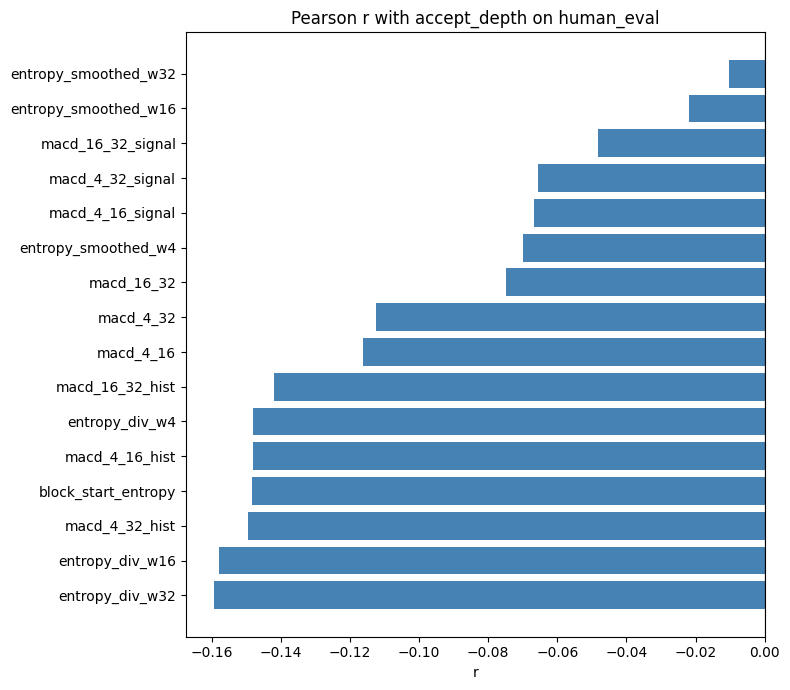

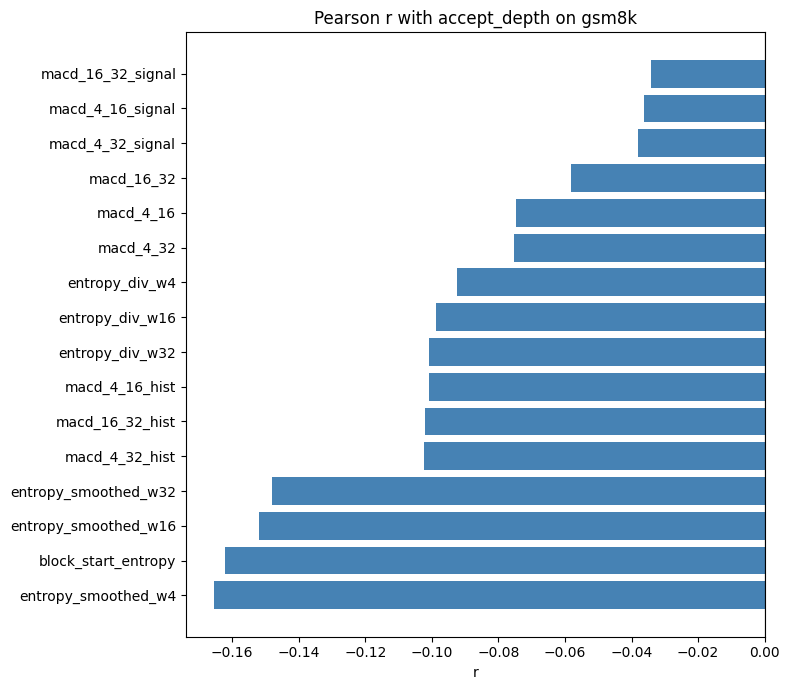

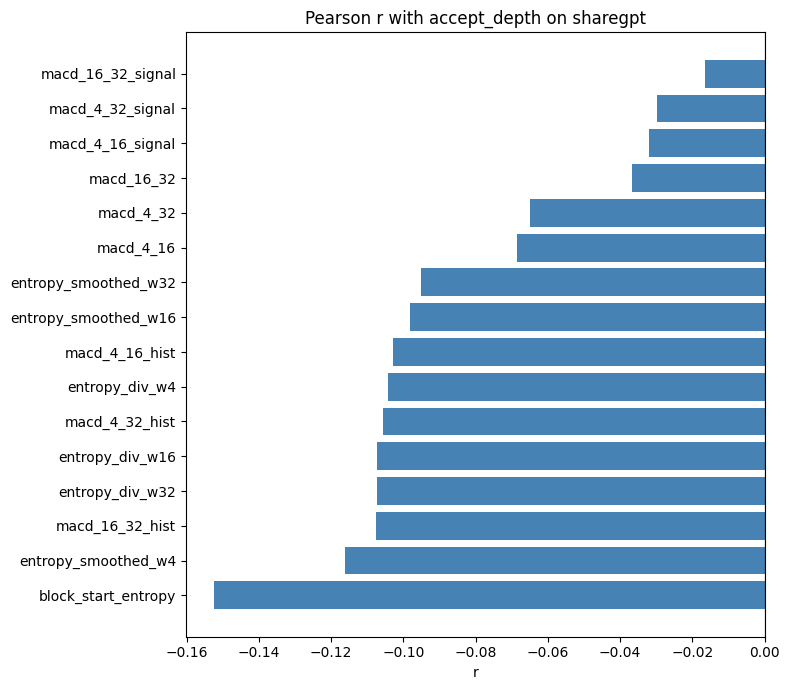

In [24]:
for dataset, dfs in transformed.items():
    pearson_df = dfs['parson']
    fig, ax = plt.subplots(figsize=(8, 7))
    colors = ['tomato' if v > 0 else 'steelblue' for v in pearson_df['pearson_r']]
    ax.barh(pearson_df['feature'], pearson_df['pearson_r'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Pearson r with accept_depth on {dataset}')
    ax.set_xlabel('r')
    plt.tight_layout()
    plt.show()

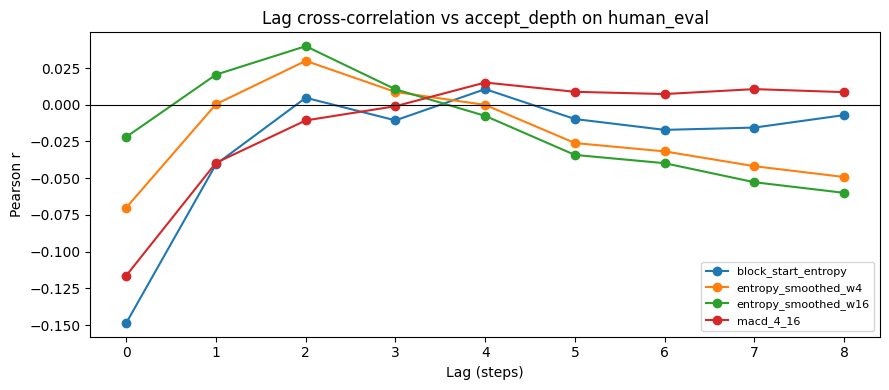

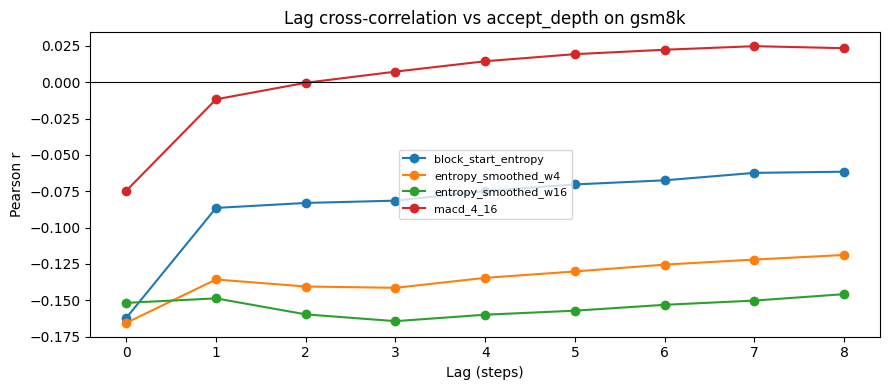

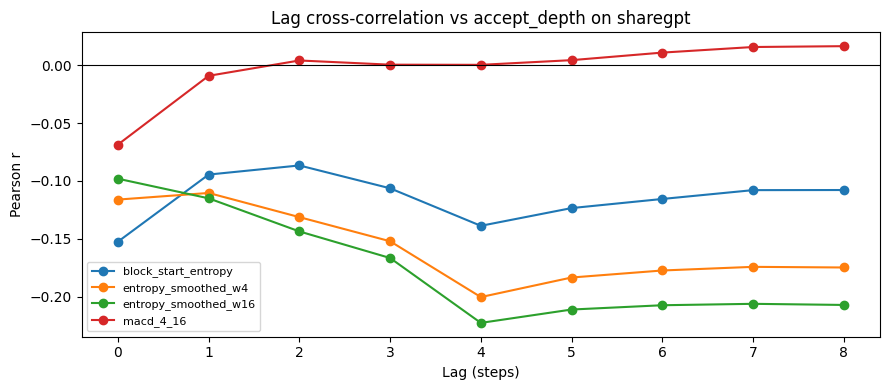

In [25]:
max_lag = 8
lag_feats = ['block_start_entropy', 'entropy_smoothed_w4',
             'entropy_smoothed_w16', 'macd_4_16']

for datasets, dfs in transformed.items():
    macd_df = dfs['raw']
    lag_results = {}
    for feat in lag_feats:
        rows = []
        for lag in range(0, max_lag + 1):
            shifted = macd_df.groupby('sample_idx')[feat].shift(lag)
            valid   = macd_df[[target_col]].join(shifted.rename('s')).dropna()
            r, p    = stats.pearsonr(valid['s'], valid[target_col])
            rows.append({'lag': lag, 'r': r, 'p': p})
        lag_results[feat] = pd.DataFrame(rows)

    # plot
    fig, ax = plt.subplots(figsize=(9, 4))
    for feat, res in lag_results.items():
        ax.plot(res['lag'], res['r'], marker='o', label=feat)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lag cross-correlation vs accept_depth on {datasets}')
    ax.set_xlabel('Lag (steps)')
    ax.set_ylabel('Pearson r')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    lag_results['block_start_entropy']

    dfs['lagged'] = lag_results

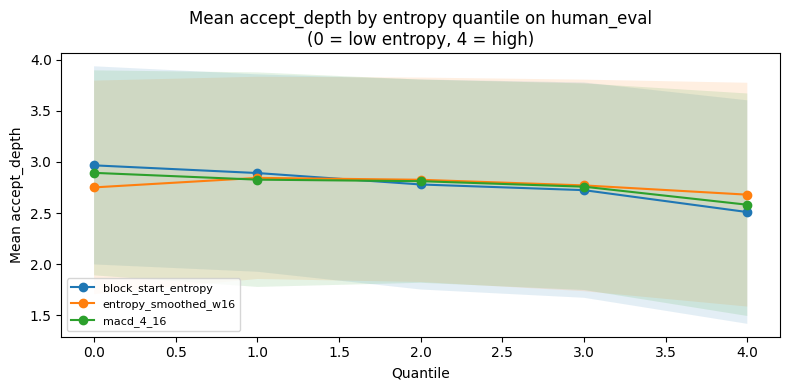

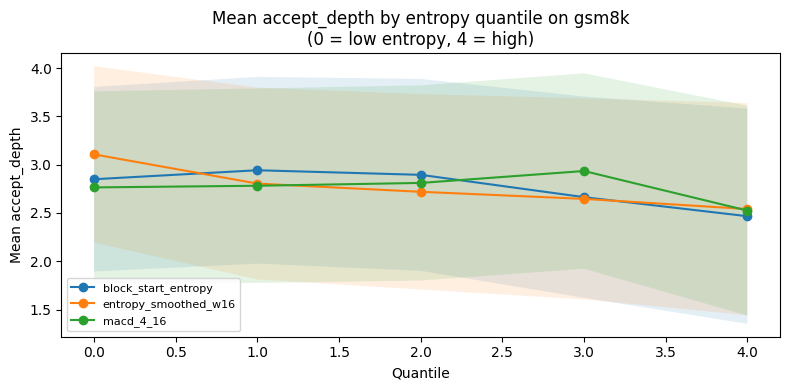

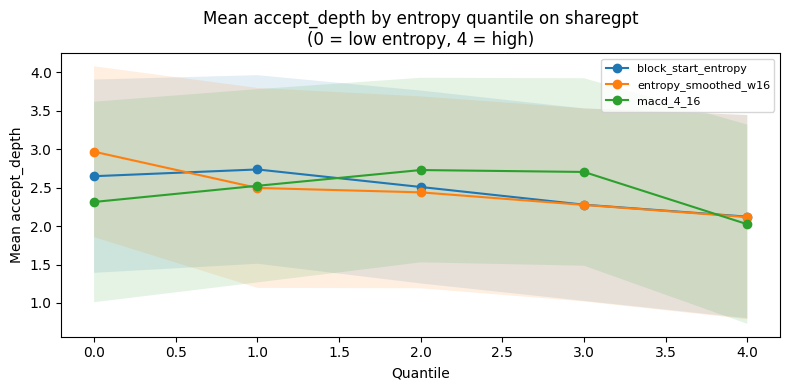

In [ ]:
bucket_feats = ['block_start_entropy', 'entropy_smoothed_w16', 'macd_4_16']

for dataset, dfs in transformed.items():
    macd_df = dfs['raw']
    
    fig, ax = plt.subplots(figsize=(8, 4))
    for feat in bucket_feats:
        tmp = macd_df[[feat, target_col]].dropna().copy()
        tmp['q'] = pd.qcut(tmp[feat], q=5, labels=False, duplicates='drop')
        bkt = tmp.groupby('q')[target_col].agg(['mean', 'std'])
        ax.plot(bkt.index, bkt['mean'], marker='o', label=feat)
        ax.fill_between(bkt.index,
                        bkt['mean'] - bkt['std'],
                        bkt['mean'] + bkt['std'], alpha=0.12)

    ax.set_title(f'Mean accept_depth by entropy quantile on {dataset}\n(0 = low entropy, 4 = high)')
    ax.set_xlabel('Quantile')
    ax.set_ylabel('Mean accept_depth')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    dfs['buckets'] = bkt

Entropy macd histograms on human_eval


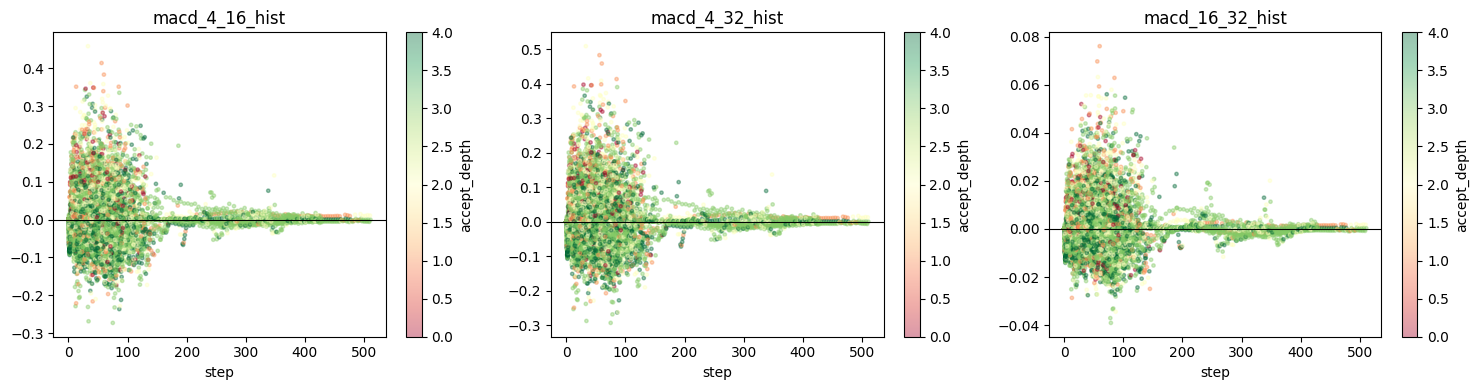

Entropy macd histograms on gsm8k


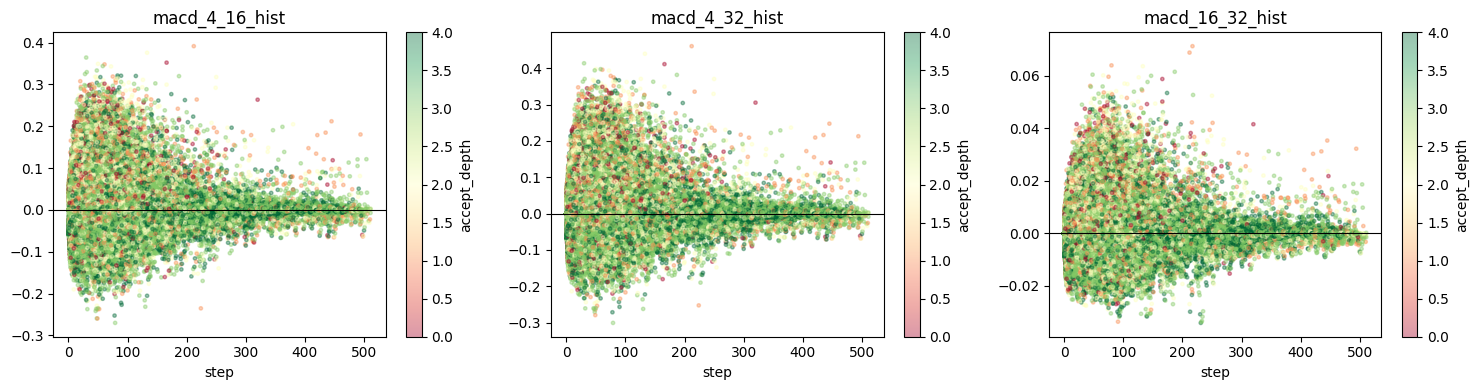

Entropy macd histograms on sharegpt


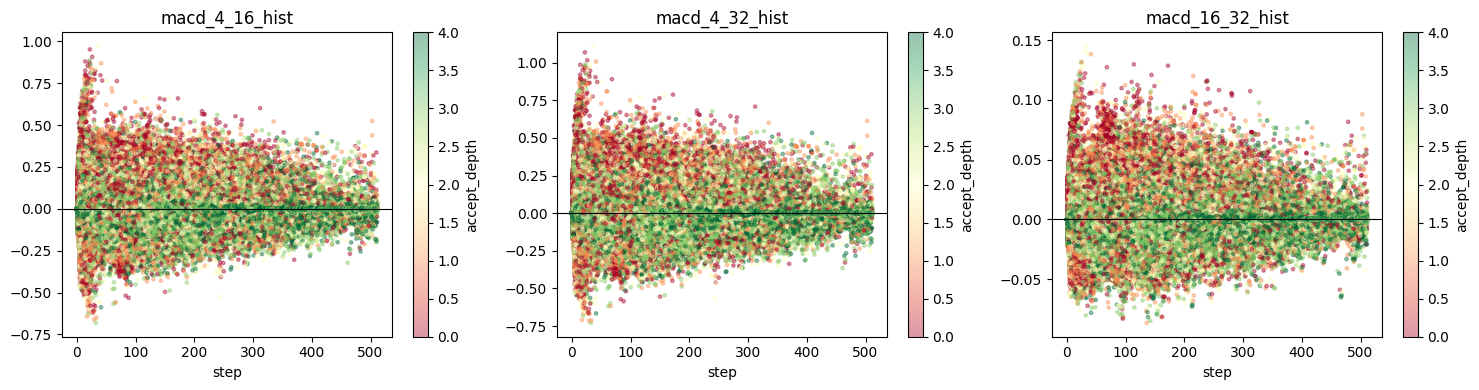

In [29]:
for dataset, dfs in transformed.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    macd_df = dfs['raw']
    for ax, col in zip(axes, ['macd_4_16_hist', 'macd_4_32_hist', 'macd_16_32_hist']):
        sc = ax.scatter(macd_df['step'], macd_df[col],
                        c=macd_df['accept_depth'], cmap='RdYlGn', alpha=0.4, s=6)
        plt.colorbar(sc, ax=ax, label='accept_depth')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(col)
        ax.set_xlabel('step')
        
    print(f'Entropy macd histograms on {dataset}')
    plt.tight_layout()
    plt.show()

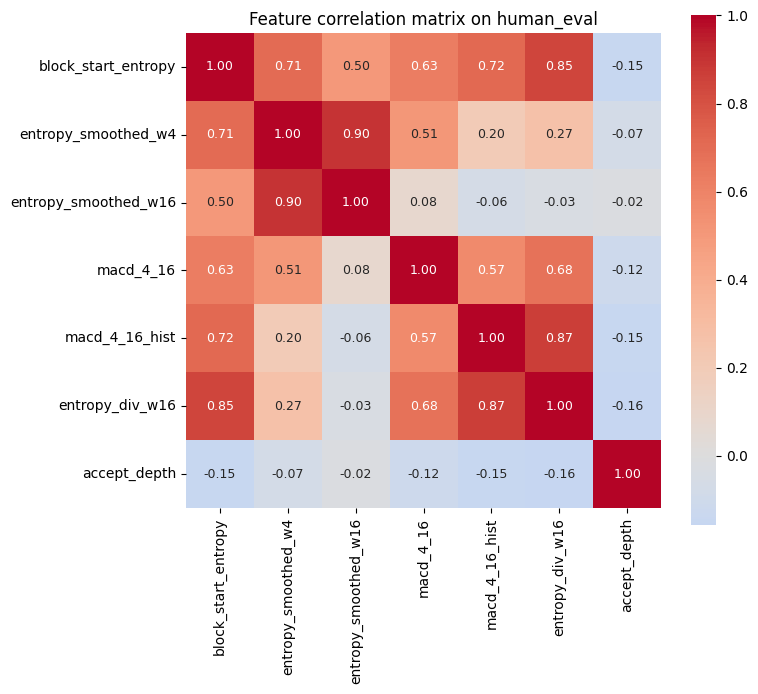

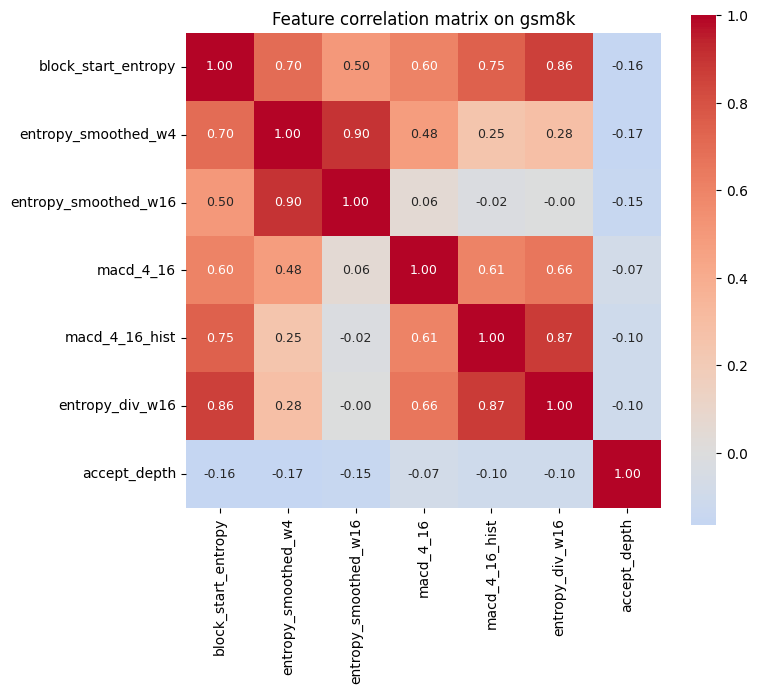

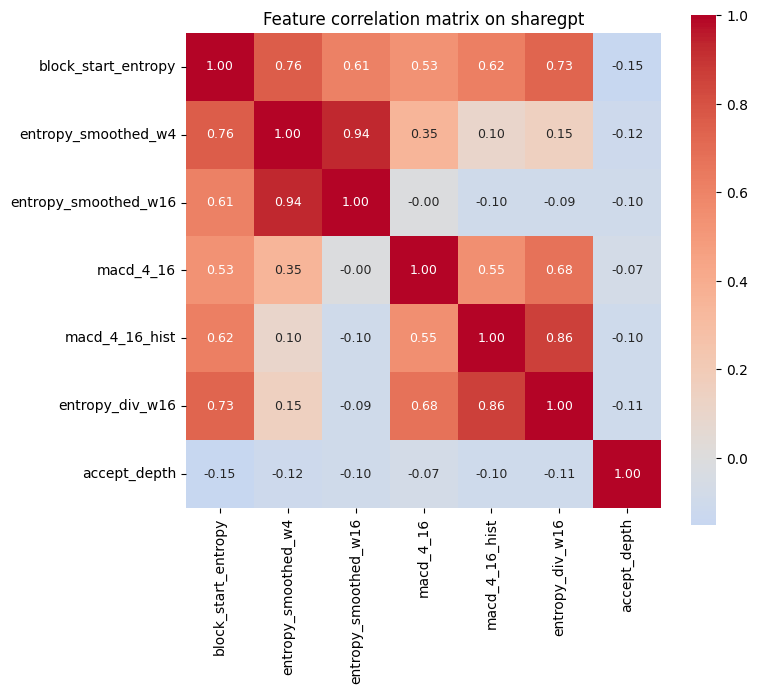

In [ ]:
heat_cols = [
    'block_start_entropy', 'entropy_smoothed_w4', 'entropy_smoothed_w16',
    'macd_4_16', 'macd_4_16_hist', 'entropy_div_w16', 'accept_depth'
]

for dataset, dfs in transformed.items():
    macd_df = dfs['raw']
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(
        macd_df[heat_cols].dropna().corr(),
        ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, square=True, annot_kws={'size': 9}
    )
    ax.set_title(f'Feature correlation matrix on {dataset}')
    plt.tight_layout()
    plt.show()